In [1]:
import json, time, random
from pathlib import Path
import numpy as np
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(torch.__version__, device)

MEMBER_DIR = Path.cwd().parent            # .../task1_llm/manjot
DATA_DIR = MEMBER_DIR / "data_processed"
DATA_DIR.mkdir(exist_ok=True)
print(MEMBER_DIR)

2.8.0+cu128 cuda
/workspace/lab1/task1_llm/manjot


In [2]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories", split="train")
print("Full train split:", len(ds))

N_TRAIN, N_VAL = 100_000, 10_000
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(ds))

# walk through the shuffled order, skipping empty stories, until we have exactly 110K
texts, kept_idx = [], []
for i in perm:
    t = ds[int(i)]["text"].strip()
    if t:
        texts.append(t); kept_idx.append(int(i))
    if len(texts) == N_TRAIN + N_VAL:
        break

np.save(DATA_DIR / "split_indices.npy", np.array(kept_idx))   # so your split can be reproduced
train_texts, val_texts = texts[:N_TRAIN], texts[N_TRAIN:]
print(len(train_texts), len(val_texts))

Full train split: 2119719


100000 10000


In [3]:
lens = np.array([len(t) for t in train_texts])
print(f"chars per story: mean {lens.mean():.0f}, median {np.median(lens):.0f}, max {lens.max()}")
print("total train chars:", lens.sum())
print("\nExample story:\n", train_texts[0][:500])

chars per story: mean 894, median 787, max 4216
total train chars: 89408301

Example story:
 Tim and Mia like to play in the park. They see a big club on the ground. It is brown and long and heavy.

"Look, a club!" Tim says. "I can lift it!"

He tries to lift the club, but it is too tough. He falls down and drops the club.

"Ouch!" he says. "That hurt!"

Mia laughs. She is not mean, she just thinks it is funny.

"Let me try!" she says. "I can balance it!"

She picks up the club and puts it on her head. She walks slowly and carefully. She does not fall down.

"Wow!" Tim says. "You are go


In [4]:
train_chars = sorted(set("".join(train_texts)))

SPECIALS = ["<unk>", "<eos>"]
itos_list = SPECIALS + train_chars
char_to_idx = {ch: i for i, ch in enumerate(itos_list)}
idx_to_char = {i: ch for i, ch in enumerate(itos_list)}
UNK, EOS = char_to_idx["<unk>"], char_to_idx["<eos>"]
vocab_size = len(itos_list)
print("vocab size:", vocab_size)
print(repr("".join(train_chars)))

vocab size: 115
'\t\n !"$%&\'()*+,-./0123456789:;=>?ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]_`abcdefghijklmnopqrstuvwxyz\xa0¡¦¨©ª¯±²´ÂÃÑâîœŠ˜–“”‹€™'


In [5]:
def encode(s):
    return [char_to_idx.get(c, UNK) for c in s]

def decode(ids):
    return "".join(idx_to_char[i] for i in ids if i not in (UNK, EOS))

def encode_corpus(stories):
    out = []
    for s in stories:
        out.extend(encode(s))
        out.append(EOS)
    return np.array(out, dtype=np.uint16)

t0 = time.time()
train_ids = encode_corpus(train_texts)
val_ids = encode_corpus(val_texts)
print(f"train tokens: {len(train_ids):,}  val tokens: {len(val_ids):,}  ({time.time()-t0:.1f}s)")
print("unknown chars in val:", int((val_ids == UNK).sum()))
assert decode(encode(train_texts[0])) == train_texts[0]

train tokens: 89,508,301  val tokens: 8,944,320  (8.2s)
unknown chars in val: 3


In [6]:
from torch.utils.data import Dataset, DataLoader

class CharDataset(Dataset):
    """Non-overlapping chunks: x = ids[i:i+T], y = ids[i+1:i+T+1]"""
    def __init__(self, ids, block_size):
        self.ids = torch.from_numpy(ids.astype(np.int64))
        self.T = block_size
        self.n = (len(self.ids) - 1) // block_size
    def __len__(self):
        return self.n
    def __getitem__(self, i):
        s = i * self.T
        chunk = self.ids[s : s + self.T + 1]
        return chunk[:-1], chunk[1:]

BLOCK_SIZE = 256
train_ds = CharDataset(train_ids, BLOCK_SIZE)
val_ds = CharDataset(val_ids, BLOCK_SIZE)
print("train sequences:", len(train_ds), " val sequences:", len(val_ds))

x, y = train_ds[0]
print("x:", repr(decode(x[:60].tolist())))
print("y:", repr(decode(y[:60].tolist())))

train sequences: 349641  val sequences: 34938
x: 'Tim and Mia like to play in the park. They see a big club on'
y: 'im and Mia like to play in the park. They see a big club on '


In [7]:
np.save(DATA_DIR / "train_ids.npy", train_ids)
np.save(DATA_DIR / "val_ids.npy", val_ids)
meta = {
    "seed": SEED, "n_train_stories": len(train_texts), "n_val_stories": len(val_texts),
    "vocab_size": vocab_size, "itos": itos_list, "block_size": BLOCK_SIZE,
    "train_tokens": int(len(train_ids)), "val_tokens": int(len(val_ids)),
}
(DATA_DIR / "meta.json").write_text(json.dumps(meta, ensure_ascii=False, indent=1))
print("saved to", DATA_DIR)

saved to /workspace/lab1/task1_llm/manjot/data_processed


In [8]:
import math
import torch.nn as nn
import torch.nn.functional as F

cfg = dict(
    vocab_size = vocab_size,
    block_size = BLOCK_SIZE,   # 256
    n_layer    = 4,            # number of Transformer blocks
    n_head     = 4,            # attention heads per block
    d_model    = 256,          # embedding size
    dropout    = 0.1,
)
print(cfg)

{'vocab_size': 115, 'block_size': 256, 'n_layer': 4, 'n_head': 4, 'd_model': 256, 'dropout': 0.1}


In [9]:
class LayerNorm(nn.Module):
    """Normalise each token's vector to mean 0, variance 1, then scale and shift."""
    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d))
        self.bias = nn.Parameter(torch.zeros(d))
        self.eps = eps
    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        var = x.var(-1, keepdim=True, unbiased=False)
        return self.weight * (x - mean) / torch.sqrt(var + self.eps) + self.bias


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_head, block_size, dropout):
        super().__init__()
        assert d_model % n_head == 0
        self.n_head, self.head_dim = n_head, d_model // n_head
        self.qkv = nn.Linear(d_model, 3 * d_model)    # makes Q, K, V in one matrix multiply
        self.proj = nn.Linear(d_model, d_model)       # mixes the heads back together
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        # lower-triangular mask: position t may only look at positions 0..t
        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("mask", mask, persistent=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)                          # each (B, T, C)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)   # (B, h, T, hd)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)     # (B, h, T, T) similarity scores
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))  # hide the future
        att = F.softmax(att, dim=-1)                                   # each row sums to 1
        att = self.attn_drop(att)

        out = att @ v                                                  # weighted sum of values
        out = out.transpose(1, 2).contiguous().view(B, T, C)           # join the heads
        return self.resid_drop(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, d_model, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Pre-norm Transformer block: x + Attention(LN(x)), then x + FFN(LN(x))."""
    def __init__(self, d_model, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_head, block_size, dropout)
        self.ln2 = LayerNorm(d_model)
        self.ffn = FeedForward(d_model, dropout)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))    # residual connection 1
        x = x + self.ffn(self.ln2(x))     # residual connection 2
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size, block_size, n_layer, n_head, d_model, dropout):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)   # what character is it?
        self.pos_emb = nn.Embedding(block_size, d_model)   # where is it in the sequence?
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d_model, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)      # scores for the next character
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(self.ln_f(x))                # (B, T, vocab)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

In [10]:
model = GPT(**cfg).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")

# 1) loss at the start should be about ln(vocab_size): the model is guessing uniformly
xb, yb = next(iter(DataLoader(train_ds, batch_size=8, shuffle=True)))
xb, yb = xb.to(device), yb.to(device)
_, loss = model(xb, yb)
print(f"initial loss: {loss.item():.3f}   expected ≈ ln({vocab_size}) = {math.log(vocab_size):.3f}")

# 2) causality test: changing a FUTURE character must not change predictions for EARLIER positions
model.eval()
with torch.no_grad():
    a = xb[:1].clone(); b = a.clone()
    b[0, 100] = (b[0, 100] + 1) % vocab_size          # change position 100 only
    la, _ = model(a); lb, _ = model(b)
    print("positions 0-99 unchanged:", torch.allclose(la[0, :100], lb[0, :100], atol=1e-5))
    print("position 100+ changed:  ", not torch.allclose(la[0, 100:], lb[0, 100:], atol=1e-5))
model.train()

parameters: 3,284,083


initial loss: 4.862   expected ≈ ln(115) = 4.745
positions 0-99 unchanged: True
position 100+ changed:   True


GPT(
  (tok_emb): Embedding(115, 256)
  (pos_emb): Embedding(256, 256)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (ln1): LayerNorm()
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (resid_drop): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm()
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (ln_f): LayerNorm()
  (lm_head): Linear(in_features=256, out_features=115, bias=True)
)

In [11]:
model = GPT(**cfg).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
for step in range(200):
    _, loss = model(xb, yb)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 40 == 0 or step == 199:
        print(step, round(loss.item(), 3))

0 4.734


40 2.305


80 1.364


120 0.315


160 0.113


199 0.065


In [12]:
import csv
from contextlib import nullcontext
from torch.utils.data import Subset

SMOKE = False   # True = quick test on Mac. False on the 5090 for the real run.

TRAIN = dict(batch_size=64, epochs=10, lr=6e-4, min_lr=6e-5, warmup_frac=0.03,
             weight_decay=0.1, grad_clip=1.0, eval_every=500, eval_batches=100)
if SMOKE:
    TRAIN.update(epochs=2, eval_every=25, eval_batches=10)

tr = Subset(train_ds, range(2000)) if SMOKE else train_ds
va = Subset(val_ds, range(500)) if SMOKE else val_ds
train_loader = DataLoader(tr, batch_size=TRAIN["batch_size"], shuffle=True, drop_last=True)
val_loader = DataLoader(va, batch_size=TRAIN["batch_size"], shuffle=False)

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * TRAIN["epochs"]
warmup_steps = max(1, int(TRAIN["warmup_frac"] * total_steps))
print(f"steps/epoch: {steps_per_epoch}  total steps: {total_steps}  warmup: {warmup_steps}")

def get_lr(step):
    """Linear warm-up to peak lr, then cosine decay down to min_lr."""
    lr, min_lr = TRAIN["lr"], TRAIN["min_lr"]
    if step < warmup_steps:
        return lr * (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return min_lr + 0.5 * (lr - min_lr) * (1 + math.cos(math.pi * progress))

steps/epoch: 5463  total steps: 54630  warmup: 1638


In [13]:
def autocast_ctx():
    # bf16 mixed precision on NVIDIA GPUs; normal precision on Mac
    if device == "cuda":
        return torch.autocast("cuda", dtype=torch.bfloat16)
    return nullcontext()

@torch.no_grad()
def evaluate(model, loader, max_batches=None):
    """Returns (mean cross-entropy per character, top-1 next-character accuracy)."""
    model.eval()
    tot_loss, tot_correct, tot_n = 0.0, 0, 0
    for i, (x, y) in enumerate(loader):
        if max_batches and i >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        with autocast_ctx():
            logits, loss = model(x, y)
        n = y.numel()
        tot_loss += loss.item() * n
        tot_correct += (logits.argmax(-1) == y).sum().item()
        tot_n += n
    model.train()
    return tot_loss / tot_n, tot_correct / tot_n

REPO_ROOT = MEMBER_DIR.parent.parent
LOG_DIR = REPO_ROOT / "reproducibility" / "raw_logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = MEMBER_DIR / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)
RUN_ID = time.strftime("%Y%m%d_%H%M%S") + ("_smoke" if SMOKE else "")
LOG_PATH = LOG_DIR / f"manjot_task1_{RUN_ID}.csv"
print("log file:", LOG_PATH.name)

log file: manjot_task1_20261002_045745.csv


In [14]:
torch.manual_seed(SEED)
model = GPT(**cfg).to(device)

# weight decay on weight matrices only (not biases or LayerNorm parameters)
decay = [p for n, p in model.named_parameters() if p.dim() >= 2]
no_decay = [p for n, p in model.named_parameters() if p.dim() < 2]
opt = torch.optim.AdamW([{"params": decay, "weight_decay": TRAIN["weight_decay"]},
                         {"params": no_decay, "weight_decay": 0.0}],
                        lr=TRAIN["lr"], betas=(0.9, 0.95))

# save the exact settings of this run next to its log
(LOG_DIR / f"manjot_task1_{RUN_ID}_config.json").write_text(json.dumps(
    {"model": cfg, "train": TRAIN, "seed": SEED, "device": device,
     "gpu": torch.cuda.get_device_name(0) if device == "cuda" else device,
     "torch": torch.__version__, "n_params": n_params}, indent=1))

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()

step, nan_count, spike_count, ema_loss = 0, 0, 0, None
t_start = time.time()

with open(LOG_PATH, "w", newline="") as f:
    log = csv.writer(f)
    log.writerow(["step", "epoch", "lr", "train_loss", "grad_norm", "tokens_per_sec",
                  "val_loss", "val_acc", "elapsed_s"])

    for epoch in range(TRAIN["epochs"]):
        for x, y in train_loader:
            t0 = time.time()
            x, y = x.to(device), y.to(device)
            lr = get_lr(step)
            for g in opt.param_groups:
                g["lr"] = lr

            with autocast_ctx():
                _, loss = model(x, y)

            if not torch.isfinite(loss):           # stability: count NaN/inf and skip the update
                nan_count += 1; opt.zero_grad(set_to_none=True); step += 1
                continue

            opt.zero_grad(set_to_none=True)
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), TRAIN["grad_clip"]).item()
            opt.step()

            loss_val = loss.item()                 # .item() also waits for the GPU to finish
            tps = x.numel() / (time.time() - t0)

            # stability: a "spike" is a loss more than 1.5x the recent average
            if ema_loss is not None and loss_val > 1.5 * ema_loss:
                spike_count += 1
            ema_loss = loss_val if ema_loss is None else 0.98 * ema_loss + 0.02 * loss_val

            val_loss = val_acc = ""
            if step % TRAIN["eval_every"] == 0:
                val_loss, val_acc = evaluate(model, val_loader, TRAIN["eval_batches"])
                print(f"ep {epoch} step {step:6d} | lr {lr:.2e} | train {loss_val:.4f} | "
                      f"val {val_loss:.4f} | acc {val_acc:.3f} | gn {grad_norm:.2f} | {tps:,.0f} tok/s")

            log.writerow([step, epoch, f"{lr:.6e}", f"{loss_val:.5f}", f"{grad_norm:.4f}",
                          f"{tps:.0f}", val_loss, val_acc, f"{time.time()-t_start:.1f}"])
            step += 1

        f.flush()
        # end of epoch: checkpoint (model + optimizer, so a run can be resumed)
        ckpt = {"model": model.state_dict(), "opt": opt.state_dict(), "step": step,
                "epoch": epoch, "cfg": cfg, "train": TRAIN, "itos": itos_list, "run_id": RUN_ID}
        torch.save(ckpt, CKPT_DIR / f"{RUN_ID}_epoch{epoch+1}.pt")
        print(f"=== epoch {epoch+1} done, checkpoint saved ===")

total_time = time.time() - t_start
peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9 if device == "cuda" else None
summary = {"run_id": RUN_ID, "total_time_s": round(total_time, 1), "steps": step,
           "nan_count": nan_count, "spike_count": spike_count, "peak_mem_gb": peak_mem_gb}
(LOG_DIR / f"manjot_task1_{RUN_ID}_summary.json").write_text(json.dumps(summary, indent=1))
print(summary)

ep 0 step      0 | lr 3.66e-07 | train 4.8562 | val 4.8669 | acc 0.009 | gn 7.07 | 51,545 tok/s


ep 0 step    500 | lr 1.84e-04 | train 2.2034 | val 2.1307 | acc 0.361 | gn 0.67 | 517,766 tok/s


ep 0 step   1000 | lr 3.67e-04 | train 1.5479 | val 1.4333 | acc 0.562 | gn 1.13 | 513,368 tok/s


ep 0 step   1500 | lr 5.50e-04 | train 1.2235 | val 1.1353 | acc 0.648 | gn 0.78 | 518,106 tok/s


ep 0 step   2000 | lr 6.00e-04 | train 1.0896 | val 0.9914 | acc 0.690 | gn 0.57 | 538,284 tok/s


...

ep 9 step  53000 | lr 6.13e-05 | train 0.6431 | val 0.6059 | acc 0.807 | gn 0.39 | 536,485 tok/s


ep 9 step  53500 | lr 6.06e-05 | train 0.6264 | val 0.6060 | acc 0.807 | gn 0.38 | 537,522 tok/s


ep 9 step  54000 | lr 6.02e-05 | train 0.6156 | val 0.6050 | acc 0.807 | gn 0.37 | 519,429 tok/s


ep 9 step  54500 | lr 6.00e-05 | train 0.6371 | val 0.6048 | acc 0.807 | gn 0.38 | 534,799 tok/s


=== epoch 10 done, checkpoint saved ===
{'run_id': '20261002_045745', 'total_time_s': 1829.4, 'steps': 54630, 'nan_count': 0, 'spike_count': 0, 'peak_mem_gb': 1.597820416}


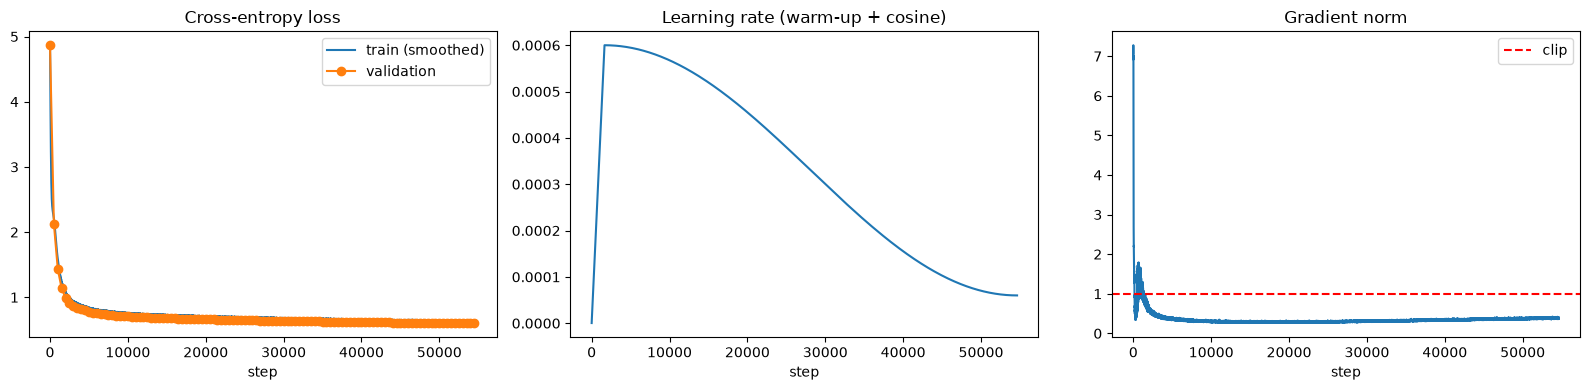

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = MEMBER_DIR / "outputs"; OUT_DIR.mkdir(exist_ok=True)
logdf = pd.read_csv(LOG_PATH)
vdf = logdf.dropna(subset=["val_loss"])

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(logdf["step"], logdf["train_loss"].rolling(50, min_periods=1).mean(), label="train (smoothed)")
ax[0].plot(vdf["step"], vdf["val_loss"], "o-", label="validation")
ax[0].set_title("Cross-entropy loss"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].plot(logdf["step"], logdf["lr"]); ax[1].set_title("Learning rate (warm-up + cosine)"); ax[1].set_xlabel("step")
ax[2].plot(logdf["step"], logdf["grad_norm"]); ax[2].axhline(TRAIN["grad_clip"], ls="--", c="r", label="clip")
ax[2].set_title("Gradient norm"); ax[2].set_xlabel("step"); ax[2].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f"training_curves_{RUN_ID}.png", dpi=150)
plt.show()

In [16]:
@torch.no_grad()
def generate(model, prompt, max_new=400, temperature=1.0, greedy=False):
    """Autoregressive generation: predict a character, append it, repeat."""
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    n_new = 0
    for _ in range(max_new):
        idx_cond = idx[:, -model.block_size:]          # the model can only see the last block_size chars
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :].float()              # scores for the next character only
        if greedy:
            nxt = logits.argmax(-1, keepdim=True)      # always pick the most likely character
        else:
            probs = F.softmax(logits / temperature, dim=-1)
            nxt = torch.multinomial(probs, 1)          # sample; low temp = safer, high = more creative
        if nxt.item() == EOS:                          # the model decided the story is finished
            break
        idx = torch.cat([idx, nxt], dim=1)
        n_new += 1
    model.train()
    return decode(idx[0].tolist()), n_new

PROMPTS = ["Once upon a time", "One day, a little girl named Lily", "Tom had a big red ball.",
           "The cat was sad because", "In a small house,"]
SETTINGS = {"greedy": dict(greedy=True), "temp_0.7": dict(temperature=0.7), "temp_1.0": dict(temperature=1.0)}

torch.manual_seed(SEED)
samples, gen_chars, t0 = {}, 0, time.time()
for name, kw in SETTINGS.items():
    samples[name] = []
    reps = 1 if name == "greedy" else 2                # greedy is deterministic, so 1 per prompt is enough
    for p in PROMPTS:
        for _ in range(reps):
            text, n = generate(model, p, **kw)
            samples[name].append(text); gen_chars += n
gen_tps = gen_chars / (time.time() - t0)
print(f"generation speed: {gen_tps:,.0f} chars/sec\n")

with open(OUT_DIR / f"samples_{RUN_ID}.txt", "w") as f:
    for name, texts in samples.items():
        for t in texts:
            f.write(f"=== {name} ===\n{t}\n\n")
for name in SETTINGS:
    print(f"--- {name} ---\n{samples[name][0][:300]}\n")

generation speed: 323 chars/sec

--- greedy ---
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big box of colorful colorful colors on the ground. She wanted to open it, but it was too heavy. She tried to open it, but it was too heavy. She tried to open it, but it was too heavy. 

--- temp_0.7 ---
Once upon a time, there was a small boy called Tim. Tim was three years old and loved to explore.

One day, Tim saw a little boy who was crying. The boy wanted to help him, so he said, "I want to help you, boy!" The boy said, "I'm sorry, but you need to stay healthy."

Tim asked, "Why do you want to

--- temp_1.0 ---
Once upon a time, there was a boy named Timmy. Timmy loved to play outside in the sun and pretend he would go on a hike. One day, he found a big box of black carrots in the grass. He decided to take it back to his home.

When he got home, he was very careful with the block on it. He got some black b



In [17]:
def ngrams(words, n):
    return [tuple(words[i:i+n]) for i in range(len(words) - n + 1)]

def distinct_n(texts, n):
    """Unique word n-grams / total word n-grams across all samples (higher = more varied)."""
    all_ng = [g for t in texts for g in ngrams(t.split(), n)]
    return len(set(all_ng)) / max(1, len(all_ng))

def repeated_4gram_rate(texts):
    """Average over samples of 1 - unique/total word 4-grams (higher = more repetition/looping)."""
    rates = []
    for t in texts:
        g = ngrams(t.split(), 4)
        if g:
            rates.append(1 - len(set(g)) / len(g))
    return float(np.mean(rates)) if rates else 0.0

div_rows = []
for name, texts in samples.items():
    div_rows.append({"setting": name, "distinct_1": distinct_n(texts, 1), "distinct_2": distinct_n(texts, 2),
                     "distinct_3": distinct_n(texts, 3), "repeated_4gram_rate": repeated_4gram_rate(texts)})
div_df = pd.DataFrame(div_rows).round(4)
div_df

,setting,distinct_1,distinct_2,distinct_3,repeated_4gram_rate
0,greedy,0.2545,0.4374,0.5300,0.3077
1,temp_0.7,0.3405,0.7140,0.8819,0.0206
2,temp_1.0,0.3935,0.8172,0.9473,0.0000


In [18]:
# Final losses with dropout OFF. Train loss is measured on a train sample the same size as validation.
n_eval = len(va)
train_eval_loader = DataLoader(Subset(tr, range(min(n_eval, len(tr)))), batch_size=TRAIN["batch_size"])
train_loss, train_acc = evaluate(model, train_eval_loader)
val_loss, val_acc = evaluate(model, val_loader)

steady = logdf["tokens_per_sec"].iloc[10:] if len(logdf) > 20 else logdf["tokens_per_sec"]
metrics = {
    "run_id": RUN_ID,
    "checkpoint": f"{RUN_ID}_epoch{TRAIN['epochs']}.pt",
    "hardware": torch.cuda.get_device_name(0) if device == "cuda" else f"Apple Silicon ({device})",
    "train_cross_entropy": train_loss,
    "val_cross_entropy": val_loss,
    "perplexity": math.exp(val_loss),
    "bits_per_character": val_loss / math.log(2),
    "generalization_gap": val_loss - train_loss,
    "top1_next_char_accuracy": val_acc,
    "grad_norm_mean": logdf["grad_norm"].mean(),
    "grad_norm_max": logdf["grad_norm"].max(),
    "frac_steps_clipped": (logdf["grad_norm"] > TRAIN["grad_clip"]).mean(),
    "nan_count": nan_count,
    "loss_spike_count": spike_count,
    "parameter_count": n_params,
    "train_tokens_per_sec": steady.median(),
    "generation_chars_per_sec": gen_tps,
    "peak_memory_gb": peak_mem_gb if peak_mem_gb is not None else "n/a (Mac)",
    "total_training_time_s": round(total_time, 1),
}
for _, r in div_df.iterrows():
    for k in ["distinct_1", "distinct_2", "distinct_3", "repeated_4gram_rate"]:
        metrics[f"{k}_{r['setting']}"] = r[k]

report = pd.DataFrame(list(metrics.items()), columns=["metric", "value"])
report.to_csv(MEMBER_DIR / "metrics_report.csv", index=False)
report

,metric,value
0,run_id,20261002_045745
1,checkpoint,20261002_045745_epoch10.pt
2,hardware,NVIDIA GeForce RTX 4090
3,train_cross_entropy,0.601065
4,val_cross_entropy,0.611236
5,perplexity,1.842707
6,bits_per_character,0.881826
7,generalization_gap,0.010171
8,top1_next_char_accuracy,0.805579
9,grad_norm_mean,0.35191
